# Demo on Cortical Self-Organisation
#### By Nicola Mendini
Demo built using the GCAL model, showing the main mechanisms behind topological map Self-Organisation, and how this extends to Salt-and-Pepper maps. 

## Ordered and Random maps emerge from similar principles, but different circuitry

In both topological maps, typical of primates and many other species, and Salt-and-Pepper maps, typical of rodents, the cortex is aiming at building efficient representations of input stimuli (the stick in the figure). This is done through a recurrent dynamic that combines excitation and inhibition (red and blue circles), making neural activity settle into specific sparse spatial patterns, thus promoting decorrelation and code efficiency. Models of self-organisation (such as the GCAL, described below) indicate that for the dynamic to produce a topological map, excitation must be short-range and usually fixed, whereas for the recurrent dynamic to produce a Salt-and-Pepper map, excitation is plastic and intertwined with inhibition into a less ordered configuration. 

<img src='demo_figs/topological_maps_fig1.png' width=500px/>

#### Importing all the necessary libraries, the simulation is implemented in PyTorch with cuda

In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from torchvision.transforms import functional as TF
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Image as IPImage
import gc
import matplotlib.colors as mcolors

from helpers.wiring_efficiency_utils import *
from neuralsheet import *
from helpers.map_plotting import *
from helpers.fig_plots import *

#### Setting up the dataloader and the key parameters of the simulated V1 sheet, such as sheet size and excitatory connection number 

In [4]:
# Example usage
crop_size = 32 # Crop size (NxN)
batch_size = 32  # Number of crops to load at once
num_workers = 4  # Number of threads for data loading
root_dir = './input_stimuli'  # Path to your image folder
device = 'cuda'  # Assuming CUDA is available and desired
R_rf = 5
beta = 1 - 5e-5
loss_beta = 1e-2

size = 60
R_pat = 12
epochs = 1

dataloader = create_dataloader(root_dir, crop_size, batch_size, num_workers)

#### Running one epoch of training over natural stimuli takek from Imagenet

In [6]:
KEEP = False
if not KEEP:
    model = NeuralSheet(size, crop_size, R_rf, R_pat=R_pat, device=device).to(device)
    lr = 1e-3

    network = init_nn(size, crop_size)
    avg_loss = 0

code_tracker = []

for e in range(epochs):

    batch_progress = tqdm(dataloader, leave=False)
    for b_idx, batch in enumerate(batch_progress):

        model.update_interactions(1,1,1)

        batch_responses = []
        batch_inputs = []
        batch = batch.to('cuda')  # Transfer the entire batch to GPU

        for image in batch:

            image = image[0:1][None].flip(1)

            if image.mean()>0.15:

                limit = 2e-4
                lr *= beta
                lr = lr if lr>limit else limit
                
                model.hebbian_lr = lr
                model.homeo_lr = lr

                model(image, noise_lvl=0.)
                model.hebbian_step()
        
        batch_progress.set_description('LR:{:.5f}'.format(lr))

## Topological maps develop from a recurrent dynamic of short-range excitation and plastic long-range inhibition
A 3D plot of the profile of inhibitory connectivity, learnt through a simple Hebbian rule. The plasticity of inhibition gives it the typical 'patchiness' appearence that can be observed in animal species too.

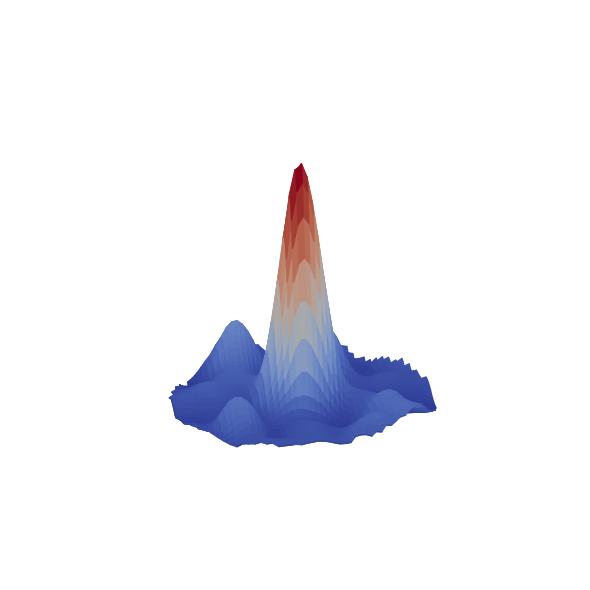

In [7]:
Z = model.lateral_correlations[size**2//2 + size//2, 0].cpu()
plot_mexican_hat(Z, r=25)  # Adjust r to your matrix scale

## Training complete!
We can not plot some components of the map to observe how the development process went. In order, we have an example of the natural input that was presented to the map, the corresponding afferent response (ie: the raw increase in potential that is caused by the input passing through the afferent weights); short-range excitation for a sampled neuron i; plastic inhibition (masked in the centre); the complete profile of lateral correlations between neuron i and all other neurons; two histograms depicting the distribution of firing rates in this activity map and on average; the resulting orientation map; the histogram of learnt orientation preferences; the fourier spectrum of the map; with its typical 'ring'; indicating periodic structure; and the learnt afferent weights for neuron i.

torch.Size([11, 3, 32, 32])
Net Afferent Max: 0.182, Net Afferent Min: -0.281
L4 Thresholds Max: 0.374, L4 Thresholds Min: 0.312
Mean current response: 0.053
L4 Strength: 2.000 aff strength: 0.319
Reco loss: 0.191%


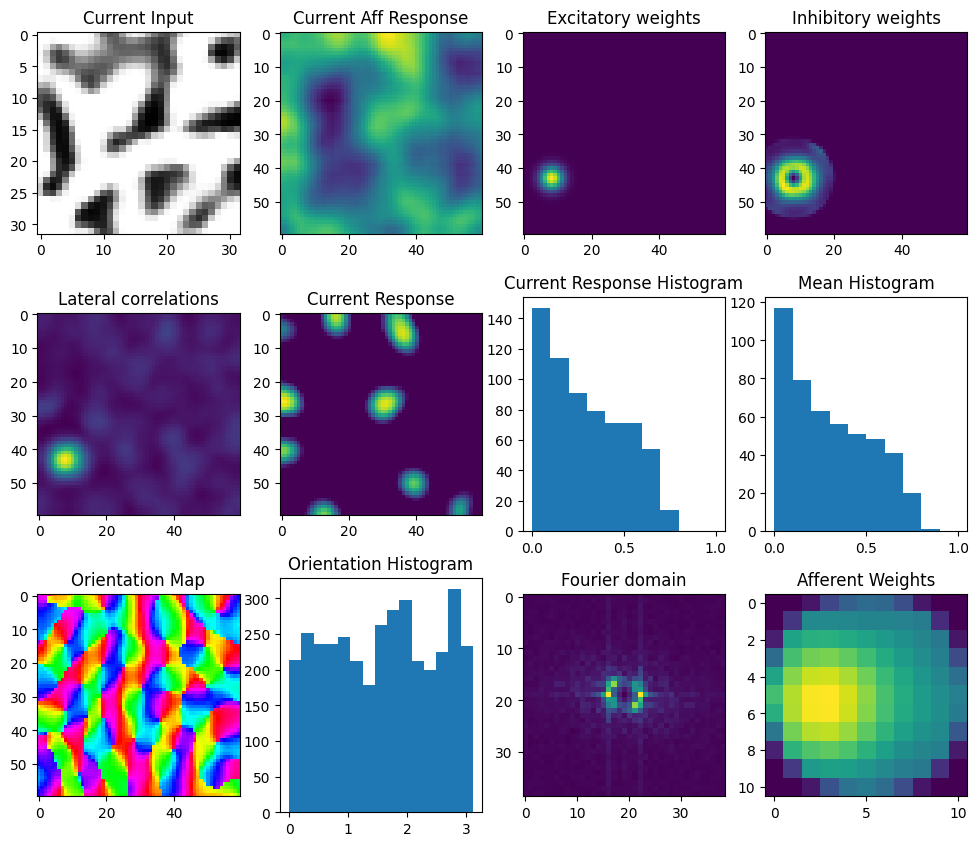

In [11]:
%matplotlib inline
#model.update_interactions(1,1,1)
random_sample = random.randint(0, model.afferent_weights.shape[0] - 1)
random_batch = random.randint(0, batch.shape[0] - 1)
print(batch.shape)

#%lprun -f model.forward model.forward(batch[random_batch, 0:1][None].flip(1),rf_grids)
model.forward(batch[random_batch, 0:1][None].flip(1).cuda(), performance_mode=False, noise_lvl=0., noise_temporal_corr=0., phi_long=1, phi_short=1., phi_mid=1)
show_map(model, network, random_sample)
model.current_response.max()
array = model.response_tracker.cpu()[:,0]
array[:,0,0] = 1
anim = animate(array, model.iterations)

### The recurrent dynamic makes activity converge to a settled state
The visualisation shows activity progressively converging to a sparse code made of 'bubbles' with approximately equal size and spacing, which underlie the learning of domains

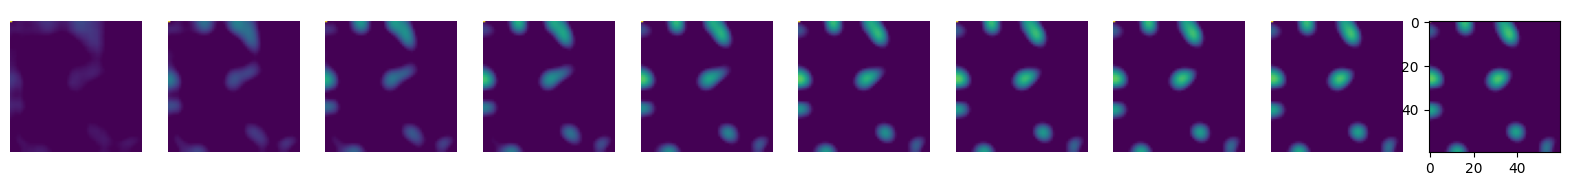

In [20]:
plt.figure(figsize=(20,2))
for i in range(10):
    plt.axis('off')
    plt.subplot(1,10,i+1)
    plt.imshow(array[i*2])
plt.show()

## Receptive field development slightly 'bends' the retinotopic order on the local scale
On the left, the learnt afferent weights arranged as a grid, on the right, the retinotopic distortion that learning has caused

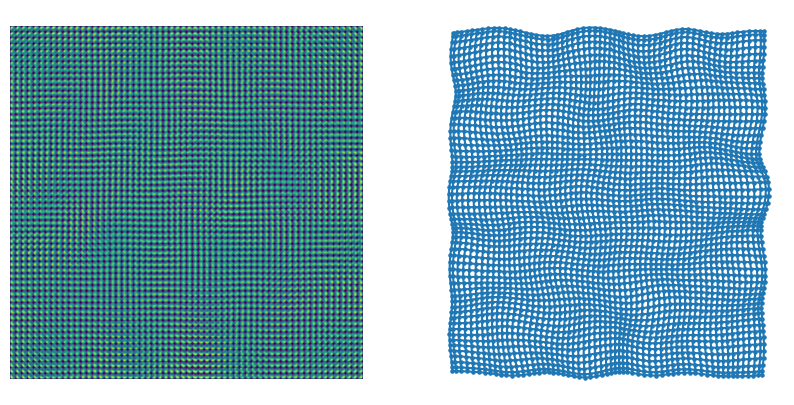

In [21]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.axis('off')
angles = model.get_aff_weights().cpu()
angles = angles.view(model.sheet_size, model.sheet_size, model.rf_size, model.rf_size)
angles = angles.permute(0,2,1,3).reshape(model.sheet_size*model.rf_size, model.sheet_size*model.rf_size)
plt.imshow(angles)
plt.subplot(1,2,2)
plt.axis('off')
plot_absolute_phases(model)

## An analysis of Accuracy and Dimensionality
So far we saw how the GCAL model leads to topological map development (the development of Salt-and-Pepper maps is omitted for the simplicity of this demo), but what do those bubbly codes 'mean'? Surely a neural code is not just there to learn pretty patterns of receptive field preferences. So, how can we quantify the meaning and performance of this learnt encoding? We can do so through a measure of reconstruction accuracy, defined by how well a simple multi-layer-perceptron (MLP) can reconstruct the original input stimulus from a neural code (panel a), between 0 and 1. if the accuracy is 1, that means that the neural codes retain complete information over the input stimuli that are encoded (which is impossible in real cases). However, for any encoding to be useful, it is not sufficient for it to be capable of reconstructing the input; it must do so in a way that the resulting neural code is a 'simplification', or a compressed version, of the original input. Otherwise, why even bother encoding something if the encoding is more complex than the input? This would clash with the observed behaviour of ealy sensory systems, which are instead seen to perform dimensionality reduction over the original input. So, we need to quantify the dimensionality of the encoding, as a proxy for its complexity, which will ultimately help tell us whetther an encoding is efficient. We do so by measuring how many PCA components are necessary to explain 95% of the variance of neural codes, and we divide that by the number of components necessary to explain 95% of the variance of the input stimulus (panel b). When plotting Accuracy in panel c, we observe that it decreases exponentially with the number of excitatory connections, at different rates dependig on the factor of cortical expansion delta. The same trend can be observed for dimensionality in panel d, where an increase of excitatory connections leads to a decrease in the number of dimensions. Interestingly, the two quantities are not independent. When plotting Accuracy against Dimensionality, we see that they lay on a common trajectory, where high levels of accuracy can only be reached by adding dimensions, and a decrease in dimensionality leads to a correspondent decrease in accuracy. An interesing observation that can be made from the GCAL is that pi pinwheel density maps only develop when the dimensionality of the code is on the same order of magnitude as the dimensionality of the stimuli. We are currently investigating the meaning of this.

<img src='demo_figs/topological_maps_fig2.png' width=720px/>